In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split, WeightedRandomSampler
from torch.optim.lr_scheduler import StepLR

from tqdm import tqdm

import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms


!pip install torchmetrics
from torchmetrics import Accuracy

import time

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:

counts = [906, 1199, 49]
class_weights = [1/count for count in counts]
batches = 16


param = 'mag labels'

training_file = 'train.pt'
training_data = torch.load(training_file, map_location = device)
training_waveforms = training_data['raw waves']
training_labels    = training_data[param]
targets = torch.argmax(torch.squeeze(training_labels, dim = 1), dim = 1)
sample_weights = [class_weights[t] for t in targets]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
trainingset = TensorDataset(training_waveforms, training_labels)
training = DataLoader(trainingset, batch_size=batches, sampler = sampler)

testing_file  = 'test.pt'
testing_data  = torch.load(testing_file, map_location = device)
testing_waveforms = testing_data['raw waves']
testing_labels    = testing_data[param]
testingset  = TensorDataset(testing_waveforms, testing_labels)
testing = DataLoader(testingset, batch_size=batches, shuffle = False)

In [14]:
classes = 3

# Define Model
class CNN(nn.Module):

    def __init__(self, num_features):
        super(CNN, self).__init__()

        self.conv1   = nn.Conv2d(1,    out_channels = 16,  kernel_size =(3,7), padding ='same')
        self.conv2   = nn.Conv2d(16,   out_channels = 64,  kernel_size =(3,7), padding ='same')
        self.conv3   = nn.Conv2d(64,   out_channels = 64,  kernel_size =(3,7), padding ='same')
        self.conv4   = nn.Conv2d(64,   out_channels = 128, kernel_size =(3,7), padding ='same')
        self.conv5   = nn.Conv2d(128,  out_channels = 256, kernel_size =(3,7), padding ='same')
        self.pool    = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 1)
        self.bn1     = nn.BatchNorm2d(16)
        self.bn2     = nn.BatchNorm2d(64)
        self.bn3     = nn.BatchNorm2d(64)
        self.bn4     = nn.BatchNorm2d(128)
        self.bn5     = nn.BatchNorm2d(256)
        self.relu    = nn.ReLU()
        self.softmax = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(p=0.5)

        self.fullyconnected = nn.LazyLinear(classes)

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)

        x = torch.flatten(x, start_dim = 1)
        x = self.fullyconnected(x)
        x = self.softmax(x)

        return x

In [15]:
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)

In [16]:
# Construct model
model = CNN(classes)
model.to(device)

print(model)

# define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
criterion = nn.CrossEntropyLoss()

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 7), stride=(1, 1), padding=same)
  (conv2): Conv2d(16, 64, kernel_size=(3, 7), stride=(1, 1), padding=same)
  (conv3): Conv2d(64, 64, kernel_size=(3, 7), stride=(1, 1), padding=same)
  (conv4): Conv2d(64, 128, kernel_size=(3, 7), stride=(1, 1), padding=same)
  (conv5): Conv2d(128, 256, kernel_size=(3, 7), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (softmax): Softmax(dim=-1)
  (dropout): Dropout(p=0.5, inplace=Fals

In [17]:
epochs = 250
model.train()

avg_losses_per_batch = []
batch_accuracies = []

start_time = time.perf_counter()

# Training
for epoch in range(epochs):

    accuracy_training = Accuracy(task="multiclass", num_classes = classes).to(device)
    all_preds = []
    all_labels = []
    batch_losses = []
    print(f"Epoch [{epoch + 1}/{epochs}]")

    for i, data in enumerate(training):

        raw_data, labels = data

        labels = torch.squeeze(labels)
        _, truth = torch.max(labels, 1)

        classification = model(raw_data.float())

        _, preds = torch.max(classification, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(truth.cpu().numpy())

        loss = criterion(classification, truth)
        accuracy_training(preds, truth)


        batch_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()

    training_accuracy = accuracy_training.compute()
    print(f"Training accuracy: {training_accuracy}")

    batch_accuracies.append(training_accuracy.cpu().item())
    avg_losses_per_batch.append(np.mean(batch_losses))
    print(f"Average loss per batch: {np.mean(batch_losses)}")
end_time = time.perf_counter()
print(f"Training time: {end_time - start_time}")

Epoch [1/250]
Training accuracy: 0.47835689783096313
Average loss per batch: 1.0217939653027226
Epoch [2/250]
Training accuracy: 0.6227915287017822
Average loss per batch: 0.9089879137529454
Epoch [3/250]
Training accuracy: 0.6877208352088928
Average loss per batch: 0.8565262610643682
Epoch [4/250]
Training accuracy: 0.7045053243637085
Average loss per batch: 0.8403044569660241
Epoch [5/250]
Training accuracy: 0.7257066965103149
Average loss per batch: 0.8161708154308964
Epoch [6/250]
Training accuracy: 0.7469081282615662
Average loss per batch: 0.8007349363515075
Epoch [7/250]
Training accuracy: 0.7508834004402161
Average loss per batch: 0.7944587548853645
Epoch [8/250]
Training accuracy: 0.7632508873939514
Average loss per batch: 0.7843380977570171
Epoch [9/250]
Training accuracy: 0.7579505443572998
Average loss per batch: 0.7874307817136738
Epoch [10/250]
Training accuracy: 0.7804770469665527
Average loss per batch: 0.7658125334222552
Epoch [11/250]
Training accuracy: 0.754858672618

250


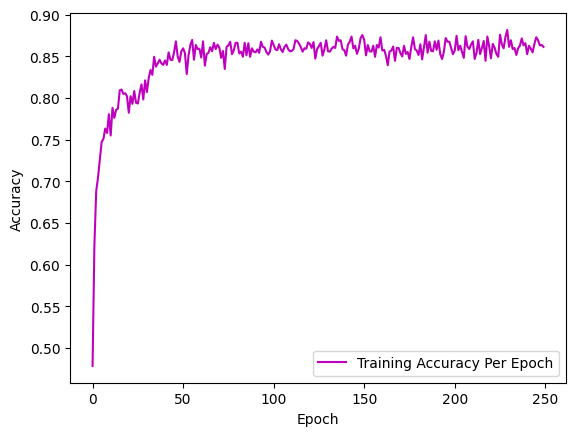

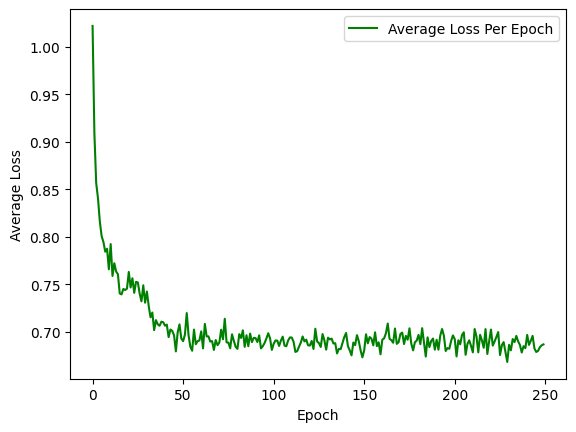

Training Accuracy: 0.8613074421882629


In [23]:

training_accuracies = np.array(batch_accuracies)
batch_losses = np.array(avg_losses_per_batch)

plt.figure()
plt.plot(training_accuracies, color = "m",   label = "Training Accuracy Per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(batch_losses, color = "g",   label = "Average Loss Per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

print(f"Training Accuracy: {training_accuracies[-1]}")

Testing Time: 0.0005368373622289765
Test accuracy: 0.8895769119262695


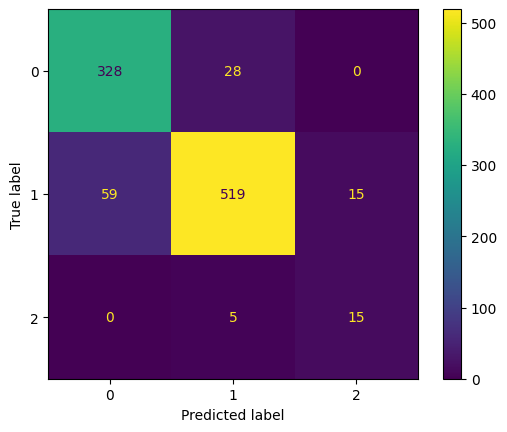

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Testing
acc = Accuracy(task="multiclass", num_classes = classes).to(device)
model.eval()

all_preds = []
all_labels = []
start_time = time.perf_counter()

with torch.no_grad():
   for i, data in enumerate(testing):

       raw_data, labels = data
       labels = torch.squeeze(labels, dim = 1)
       depth_class = model(raw_data.float())
       _, preds = torch.max(depth_class, 1)
       _, truth = torch.max(labels, 1)

       all_preds.extend(preds.cpu().numpy())
       all_labels.extend(truth.cpu().numpy())


       acc(preds, truth)

end_time = time.perf_counter()

testing_time = end_time - start_time
print(f"Testing Time: {(testing_time/969)}")
test_accuracy = acc.compute()
print(f"Test accuracy: {test_accuracy}")

# Generate matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [20]:
torch.save(model.state_dict(), "CNN_Magnitude.pth")